# AR Segmentation — results viewer

Displays the outputs of the inference / averaging / false-colour pipeline.
Runs on the default `python3` kernel — no torch, no GPU, it only reads files.

| produced by | what | where |
|---|---|---|
| `infer_file.py` | per-channel prediction panels + NetCDF, one dir per checkpoint | `~/infer_run1`, `~/infer_run2`, `~/infer_run3` |
| `average_masks.py` | pixelwise mean mask across those runs | `~/infer_mask_mean` |
| `false_color.py` | false-colour JPEG of the mean mask | `~/infer_false_color_aia94` |

Everything is 4096x4096, so each display downsamples. **Sparse mask images use
block-max, not averaging** — averaging dissolves features covering <1% of the
frame into the background and they vanish from the preview.

In [1]:
import glob
import os

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from PIL import Image

Image.MAX_IMAGE_PIXELS = None  # these are 4096x4096, above PIL's default guard

RUN_DIRS = {
    "run1 - released weights": "~/scratch_space/bathomas/infer_run1",
    "run2 - feb16 epoch_9": "~/scratch_space/bathomas/infer_run2",
    "run3 - feb17 epoch_9": "~/scratch_space/bathomas/infer_run3",
}
MEAN_DIR = "~/scratch_space/bathomas/infer_mask_mean"
FALSE_COLOR_DIR = "~/scratch_space/bathomas/infer_false_color_aia94"
# Directory holding false_color.py, imported in section 3 for its contour helpers.
SCRIPT_DIR = "."

CHANNEL = "aia94"  # change and re-run the cells below

expand = os.path.expanduser
for label, d in list(RUN_DIRS.items()) + [("mean", MEAN_DIR), ("false colour", FALSE_COLOR_DIR)]:
    path = expand(d)
    n = len(glob.glob(os.path.join(path, "*"))) if os.path.isdir(path) else 0
    print(f"{'OK ' if n else 'MISSING'}  {label:<26} {d}  ({n} files)")

OK   run1 - released weights    ~/scratch_space/bathomas/infer_run1  (16 files)
OK   run2 - feb16 epoch_9       ~/scratch_space/bathomas/infer_run2  (16 files)
OK   run3 - feb17 epoch_9       ~/scratch_space/bathomas/infer_run3  (16 files)
OK   mean                       ~/scratch_space/bathomas/infer_mask_mean  (16 files)
OK   false colour               ~/scratch_space/bathomas/infer_false_color_aia94  (2 files)


## Helpers

In [2]:
def block_max(img, factor):
    """Downsample by taking the max over each factor x factor block.

    Averaging would erase sparse features; max keeps any coloured pixel visible.
    """
    h, w = img.shape[:2]
    h, w = h - h % factor, w - w % factor  # crop to a multiple of factor
    img = img[:h, :w]
    if img.ndim == 3:
        return img.reshape(h // factor, factor, w // factor, factor, img.shape[2]).max(axis=(1, 3))
    return img.reshape(h // factor, factor, w // factor, factor).max(axis=(1, 3))


def load_preview(path, max_px=1000, sparse=False):
    """Read an image file and shrink it for inline display."""
    img = np.asarray(Image.open(path))
    factor = max(1, int(np.ceil(max(img.shape[:2]) / max_px)))
    if factor == 1:
        return img
    if sparse:
        return block_max(img, factor)
    return np.asarray(Image.fromarray(img).resize(
        (img.shape[1] // factor, img.shape[0] // factor), Image.LANCZOS))


def show(items, ncols=1, height=6, sparse=False):
    """Display (title, path) pairs in a grid."""
    items = [it for it in items if os.path.exists(it[1])]
    if not items:
        print("Nothing to show - are the result directories present?")
        return
    previews = [(title, load_preview(path, sparse=sparse)) for title, path in items]
    # Size the figure from the images' own aspect ratio; a fixed guess leaves
    # large dead bands between rows, since the 3-panel PNGs are much wider
    # than the square false-colour frames.
    h, w = previews[0][1].shape[:2]
    aspect = w / h
    nrows = int(np.ceil(len(previews) / ncols))
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(ncols * height * aspect, nrows * height)
    )
    axes = np.atleast_1d(axes).ravel()
    for ax, (title, img) in zip(axes, previews):
        ax.imshow(img)
        ax.set_title(title, fontsize=11)
        ax.axis("off")
    for ax in axes[len(previews):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


def find(directory, pattern):
    hits = sorted(glob.glob(os.path.join(expand(directory), pattern)))
    return hits[0] if hits else ""

## 1. Prediction from each checkpoint

Three panels per run: the channel image, the predicted AR probability, and the
thresholded mask overlaid. Same input file and channel throughout, so the only
thing differing between rows is the checkpoint.

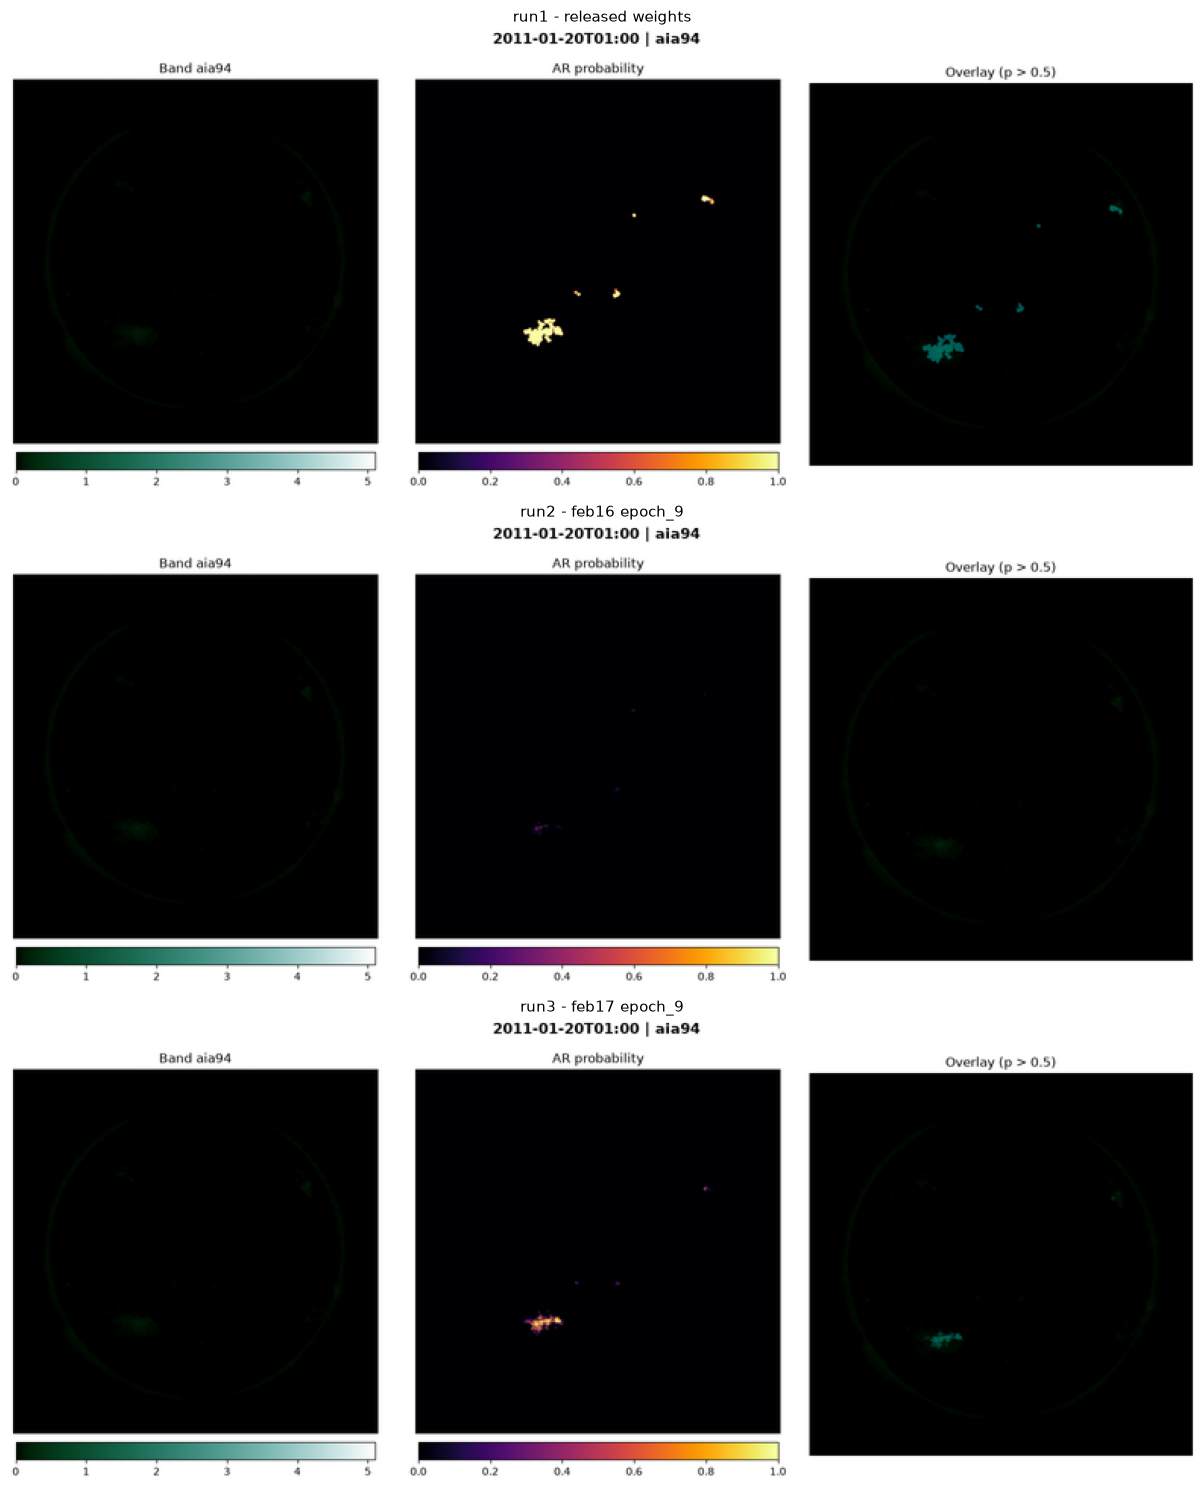

In [3]:
show(
    [(label, find(d, f"*_{CHANNEL}.png")) for label, d in RUN_DIRS.items()],
    ncols=1,
    height=5,
)

## 2. Pixelwise mean across the runs

Left is the mean mask, right is that agreement overlaid on the channel image.
A pixel's value is the fraction of runs that called it active region.

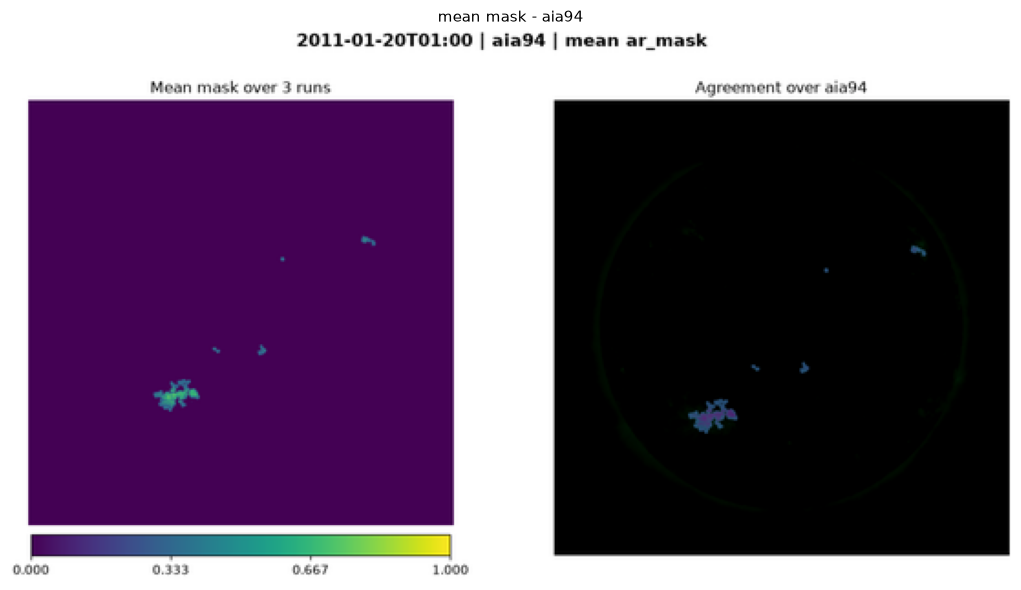

In [4]:
show([(f"mean mask - {CHANNEL}", find(MEAN_DIR, f"*_{CHANNEL}_mask_mean.png"))], height=6)

In [5]:
path = find(MEAN_DIR, f"*_{CHANNEL}_mask_mean.nc")
if path:
    with xr.open_dataset(path, engine="h5netcdf") as ds:
        mean = ds.mask_mean.values
        n_runs = ds.attrs["n_runs"]
        print(f"{ds.attrs['data_time']}  |  {ds.attrs['averaged_variable']} over {n_runs} runs")
        print(f"runs: {ds.attrs['runs']}\n")

    print(f"{'agreement':<18}{'pixels':>12}{'% of frame':>14}")
    for k in range(n_runs + 1):
        level = k / n_runs
        count = int(np.isclose(mean, level).sum())
        label = "none" if k == 0 else f"{k} of {n_runs} runs"
        print(f"{label:<18}{count:>12,}{100 * count / mean.size:>13.4f}%")

2011-01-20T01:00  |  ar_mask over 3 runs
runs: /home/jovyan/infer_run1; /home/jovyan/infer_run2; /home/jovyan/infer_run3

agreement               pixels    % of frame
none                16,699,118      99.5345%


1 of 3 runs             57,391       0.3421%
2 of 3 runs             20,250       0.1207%


3 of 3 runs                457       0.0027%


## 3. False-colour render, with contours

Single-hue sequential ramp — lighter means more runs agreed. The ramp was
checked with the data-viz palette validator against a dark surface
(`#1c5cab,#3987e5,#b7d3f6 --mode dark --ordinal`).

Contours come from `false_color.py`'s helpers. The mask average **cannot be
contoured as it stands** — it only takes the values k/n and its edges follow
Surya's 16 px patch grid, so a contour on the raw field traces that staircase
and every isolated speckle. It is therefore smoothed to the model's resolution
limit (Gaussian, FWHM = one patch) and the smoothed field is contoured.

Two levels are drawn, each in its own colour. Both were validated against every
fill they sit on and against each other, dark surface:

| level | colour | vs fills (CVD / normal ΔE) |
|---|---|---|
| 0.50 | `#d95926` orange | 22.9–28.0 / 31.8–33.1 |
| 1.00 | `#199e70` aqua | 19.6–23.7 / 20.9–27.6 |

**Expect the 1.0 contour to be empty.** Smoothing is a local average, so a level
of 1.0 requires a *solid patch-sized region* where every run agreed. Unanimous
pixels here are scattered speckle, so the smoothed field peaks well below 1.0
and nothing is drawn. The cell reports this rather than failing silently.

In [6]:
import sys

if expand(SCRIPT_DIR) not in sys.path:
    sys.path.insert(0, expand(SCRIPT_DIR))
import false_color as fcolor  # smoothing + contour helpers

# Level -> contour colour. Validated as a set; see the table above.
CONTOUR_LEVELS = {0.5: "#d95926", 1.0: "#199e70"}
CONTOUR_WIDTH = 3

fc_path = find(FALSE_COLOR_DIR, f"*_{CHANNEL}_*false_color.jpg") or find(FALSE_COLOR_DIR, "*false_color.jpg")
nc_path = find(MEAN_DIR, f"*_{CHANNEL}_mask_mean.nc")

contoured = None
if fc_path and nc_path:
    with xr.open_dataset(nc_path, engine="h5netcdf") as ds:
        mask_mean = ds.mask_mean.values

    smoothed = fcolor.smooth_to_model_resolution(mask_mean, fcolor.SURYA_PATCH_PX)
    print(f"smoothed: FWHM {fcolor.SURYA_PATCH_PX} px "
          f"(sigma {fcolor.SURYA_PATCH_PX / 2.3548:.2f} px)")
    print(f"  raw mask average max      {mask_mean.max():.4f}")
    print(f"  smoothed field max        {smoothed.max():.4f}\n")

    # Paint onto a copy of the rendered false-colour image.
    contoured = np.asarray(Image.open(fc_path)).copy()
    print(f"{'level':>7}{'enclosed px':>14}{'% frame':>10}{'contour px':>13}   status")
    for level, hexcol in sorted(CONTOUR_LEVELS.items()):
        edge = fcolor.contour_mask(smoothed, level, CONTOUR_WIDTH)
        enclosed = int((smoothed >= level).sum())
        contoured[edge] = fcolor.hex_to_rgb(hexcol)
        status = f"drawn in {hexcol}" if edge.any() else "EMPTY - field never reaches this level"
        print(f"{level:>7.2f}{enclosed:>14,}{100 * enclosed / smoothed.size:>9.4f}%"
              f"{int(edge.sum()):>13,}   {status}")
else:
    print("Missing the false-colour image or the averaged NetCDF; run the pipeline first.")

smoothed: FWHM 16 px (sigma 6.79 px)
  raw mask average max      1.0000
  smoothed field max        0.7281



  level   enclosed px   % frame   contour px   status


   0.50        17,752   0.1058%        3,016   drawn in #d95926
   1.00             0   0.0000%            0   EMPTY - field never reaches this level


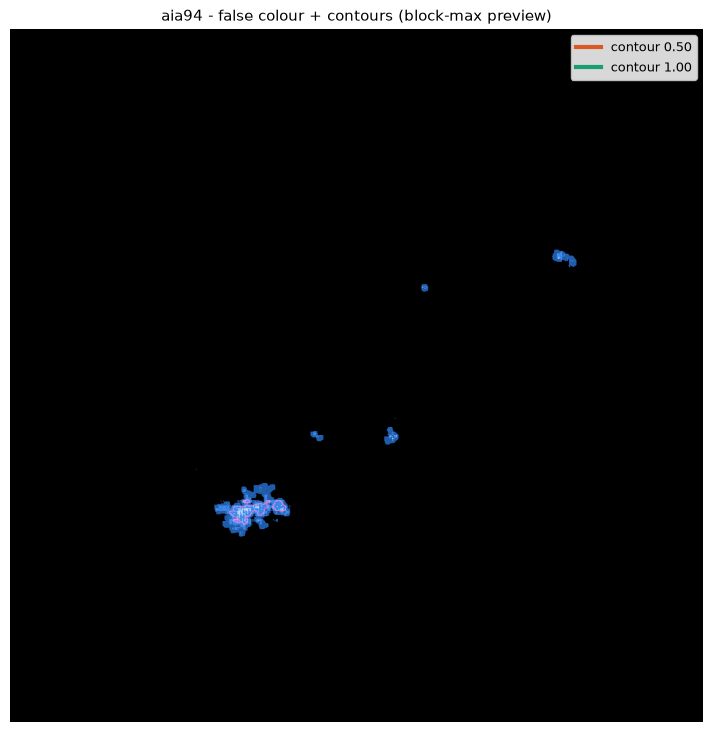

In [7]:
if contoured is not None:
    legend = [
        plt.Line2D([], [], color=c, lw=3, label=f"contour {lv:.2f}")
        for lv, c in sorted(CONTOUR_LEVELS.items())
    ]

    fig, ax = plt.subplots(figsize=(9, 9))
    ax.imshow(block_max(contoured, 4))  # max-downsample so thin lines survive
    ax.set_title(f"{CHANNEL} - false colour + contours (block-max preview)", fontsize=11)
    ax.legend(handles=legend, loc="upper right", framealpha=0.85, fontsize=9)
    ax.axis("off")
    plt.show()

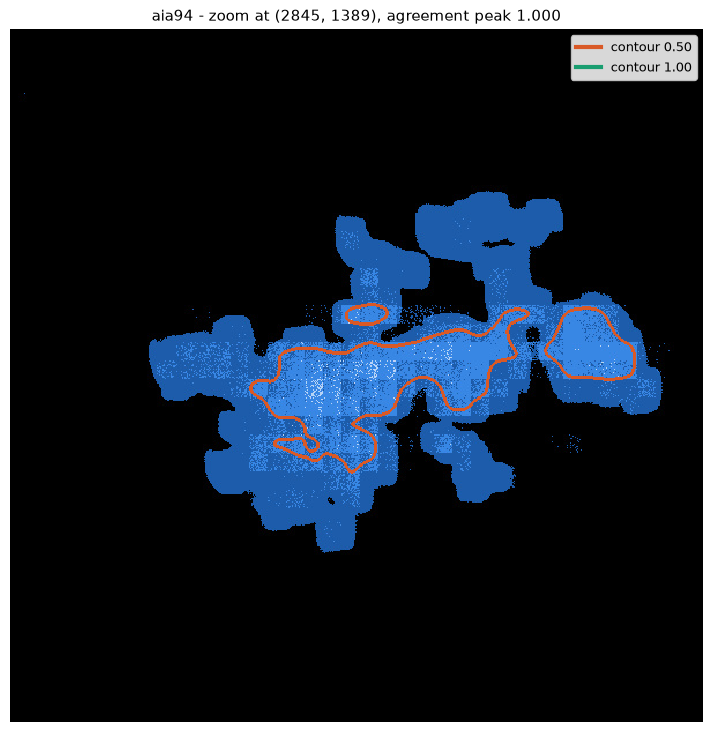

The fills keep their raw patch-aligned edges; the contour follows the
smoothed field, so it deliberately does not trace those edges.


In [8]:
if contoured is not None:
    # Centre the zoom on the highest agreement level present in the raw average.
    top = max(v for v in np.unique(mask_mean) if v > 0) if (mask_mean > 0).any() else 0
    ys, xs = np.nonzero(np.isclose(mask_mean, top))
    cy, cx = int(np.median(ys)), int(np.median(xs))
    half = 300
    y0, x0 = max(0, cy - half), max(0, cx - half)

    legend = [
        plt.Line2D([], [], color=c, lw=3, label=f"contour {lv:.2f}")
        for lv, c in sorted(CONTOUR_LEVELS.items())
    ]

    fig, ax = plt.subplots(figsize=(9, 9))
    ax.imshow(contoured[y0:y0 + 2 * half, x0:x0 + 2 * half], interpolation="nearest")
    ax.set_title(f"{CHANNEL} - zoom at ({cy}, {cx}), agreement peak {top:.3f}", fontsize=11)
    ax.legend(handles=legend, loc="upper right", framealpha=0.85, fontsize=9)
    ax.axis("off")
    plt.show()
    print("The fills keep their raw patch-aligned edges; the contour follows the")
    print("smoothed field, so it deliberately does not trace those edges.")

## 4. Browse any channel

Pick a channel to redraw sections 1-3 without editing the constant above.

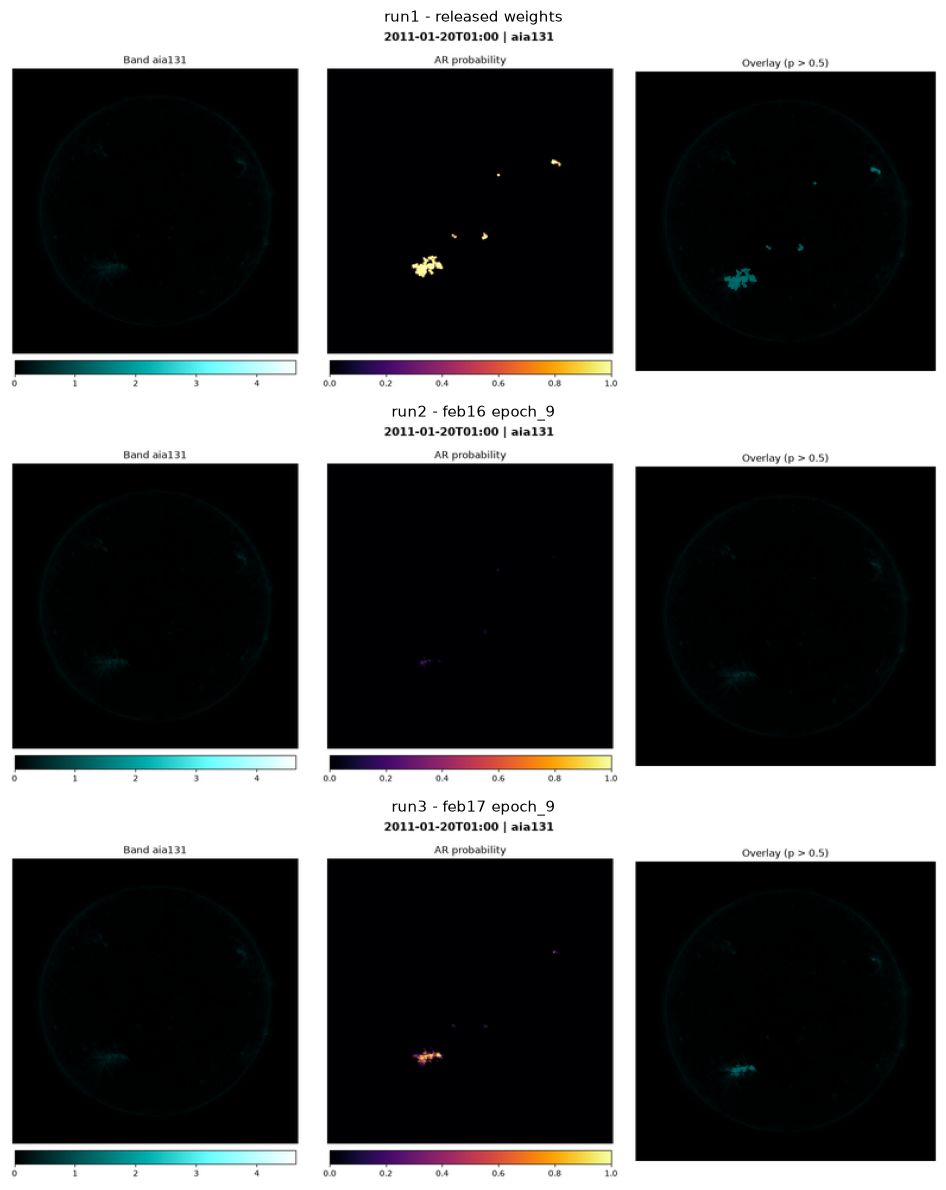

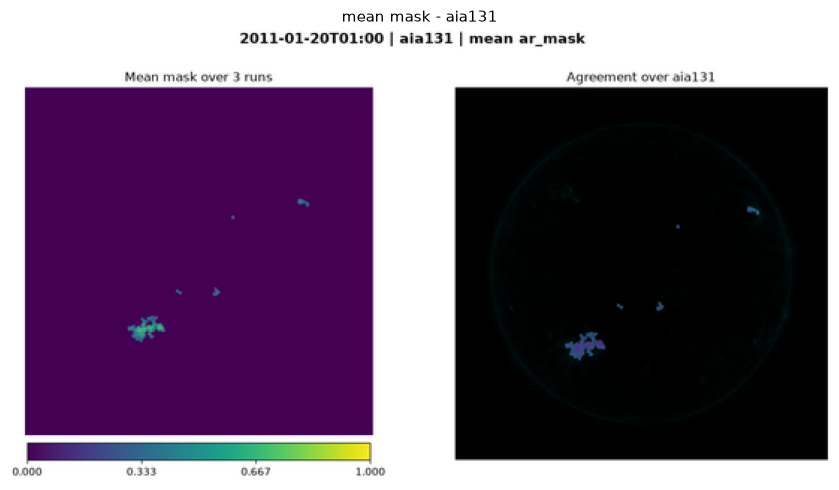

interactive(children=(Dropdown(description='channel', options=('aia131', 'aia1600', 'aia171', 'aia193', 'aia21…

In [9]:
import ipywidgets as widgets
from IPython.display import display

channels = sorted(
    os.path.basename(p).split("_")[-3]
    for p in glob.glob(os.path.join(expand(MEAN_DIR), "*_mask_mean.nc"))
)


def redraw(channel):
    show([(label, find(d, f"*_{channel}.png")) for label, d in RUN_DIRS.items()], height=4)
    show([(f"mean mask - {channel}", find(MEAN_DIR, f"*_{channel}_mask_mean.png"))], height=5)


if channels:
    widgets.interact(redraw, channel=widgets.Dropdown(options=channels, value=channels[0]))
else:
    print("No averaged files found; run average_masks.py first.")